# HumanLens AI — Face Expression & Action Unit Analysis
**Member 3: Research / ML Lead**

This notebook demonstrates **privacy-preserving facial expression feature extraction** based on geometric Action Unit (AU) ratios without identity recognition, face embeddings, or facial identification.

### Privacy & Governance Contract
- **Zero Identity**: No biometric templates, embeddings, or facial recognition are generated or stored.
- **Immediate Pixel Purge**: Raw image frames are processed in-memory for geometric landmarker calculation and purged immediately.
- **Action Unit Proxies**: AU4 (Brow Furrow), AU7 (Eye Squint), and AU15/23 (Mouth Tension/Lip Compression).


In [1]:
# ============================================================
# HumanLens AI — Notebook 10
# Face Expression & Action Unit Analysis
# Member 3 — Research / ML Lead
# ============================================================

import sys
from pathlib import Path

# ------------------------------------------------------------
# 1. Project Root
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())

# ------------------------------------------------------------
# 2. Scientific Libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

# ------------------------------------------------------------
# 3. Import HumanLens Face Extractor
# ------------------------------------------------------------

from src.face.features import FaceExpressionExtractor

# ------------------------------------------------------------
# 4. Privacy-Preserving Extractor
# ------------------------------------------------------------

extractor = FaceExpressionExtractor(
    privacy_mode=True
)

print("\nFaceExpressionExtractor initialized successfully.")
print("Privacy mode:", extractor.privacy_mode)

Project root: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml
Project root exists: True
NumPy version: 2.3.5
Pandas version: 2.3.3

FaceExpressionExtractor initialized successfully.
Privacy mode: True


## 2. Facial Feature Representation

HumanLens AI does not attempt to identify the person in an image.

Instead, the system extracts privacy-preserving geometric facial signals that can be used as broad expression/tension indicators.

The current AU-inspired proxies are:

- AU4 Proxy — Brow Furrow / Brow Activation
- AU7 Proxy — Eye Squint / Eye Activation
- AU15/23 Proxy — Mouth Tension / Lip Compression
- Face Expressive Intensity — combined geometric activation score

These are geometric proxies and should NOT be interpreted as clinically validated Facial Action Coding System (FACS) Action Units.

In [2]:
# ============================================================
# 3. Synthetic Facial Expression Scenarios
# ============================================================

scenarios = [
    {
        "name": "Relaxed / Neutral",
        "brow_distance": 0.62,
        "eye_aperture": 0.52,
        "mouth_aspect_ratio": 0.48
    },
    {
        "name": "Attentive / Mild Focus",
        "brow_distance": 0.48,
        "eye_aperture": 0.44,
        "mouth_aspect_ratio": 0.45
    },
    {
        "name": "Mild Frustration / Strain",
        "brow_distance": 0.34,
        "eye_aperture": 0.32,
        "mouth_aspect_ratio": 0.30
    },
    {
        "name": "Elevated Agitation / Tension",
        "brow_distance": 0.20,
        "eye_aperture": 0.22,
        "mouth_aspect_ratio": 0.16
    }
]

print("Number of scenarios:", len(scenarios))

pd.DataFrame(scenarios)

Number of scenarios: 4


,name,brow_distance,eye_aperture,mouth_aspect_ratio
0,Relaxed / Neutral,0.62,0.52,0.48
1,Attentive / Mild Focus,0.48,0.44,0.45
2,Mild Frustration / Strain,0.34,0.32,0.30
3,Elevated Agitation / Tension,0.20,0.22,0.16


### Privacy Verification
We verify that the extractor strictly produces non-identifying features and that no facial embeddings or personal identifiers exist in the output dictionary.


In [3]:
# ============================================================
# 4. Extract AU-Inspired Facial Features
# ============================================================

results = []

for scenario in scenarios:

    features = extractor.extract_from_landmarks(
        scenario
    )

    features["scenario"] = scenario["name"]

    results.append(features)

df_face = pd.DataFrame(results)

columns_to_show = [
    "scenario",
    "brow_activation",
    "eye_squint_activation",
    "mouth_tension",
    "face_expressive_intensity",
    "dominant_expression"
]

print("Facial Expression Feature Results:\n")

display(
    df_face[columns_to_show]
)

Facial Expression Feature Results:



,scenario,brow_activation,eye_squint_activation,mouth_tension,face_expressive_intensity,dominant_expression
0,Relaxed / Neutral,0.07,0.064,0.232,0.1252,neutral_relaxed
1,Attentive / Mild Focus,0.28,0.208,0.280,0.2620,neutral_relaxed
2,Mild Frustration / Strain,0.49,0.424,0.520,0.4840,mild_strain
3,Elevated Agitation / Tension,0.70,0.604,0.744,0.6914,agitated_tense


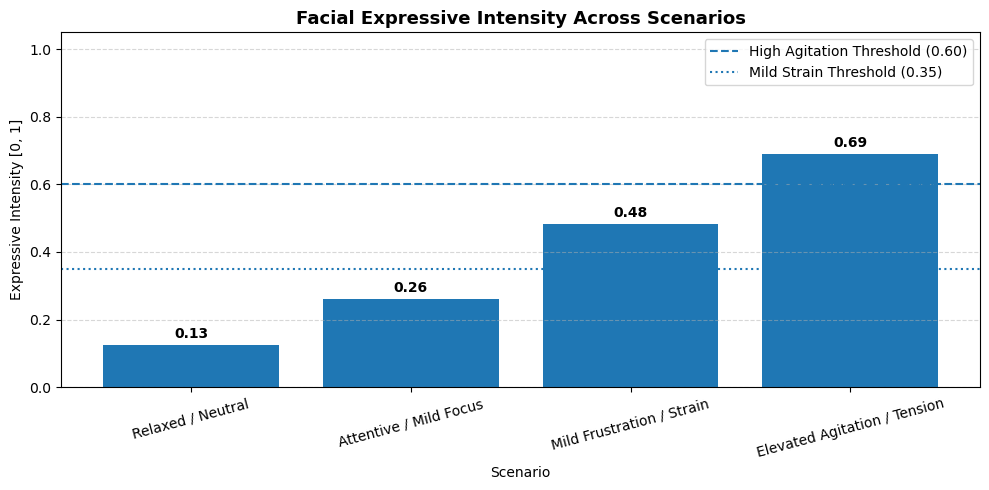

In [4]:
# ============================================================
# 5. Facial Expressive Intensity
# ============================================================

plt.figure(figsize=(10, 5))

bars = plt.bar(
    df_face["scenario"],
    df_face["face_expressive_intensity"]
)

plt.title(
    "Facial Expressive Intensity Across Scenarios",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Expressive Intensity [0, 1]"
)

plt.xlabel("Scenario")

plt.ylim(0, 1.05)

# Research thresholds used by the existing notebook
plt.axhline(
    0.60,
    linestyle="--",
    linewidth=1.5,
    label="High Agitation Threshold (0.60)"
)

plt.axhline(
    0.35,
    linestyle=":",
    linewidth=1.5,
    label="Mild Strain Threshold (0.35)"
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 6. Privacy Verification
# ============================================================

sample_output = extractor.extract_from_landmarks(
    scenarios[0]
)

# ------------------------------------------------------------
# Check privacy flag
# ------------------------------------------------------------

privacy_verified = sample_output.get(
    "privacy_verified"
)

print(
    "Privacy verified:",
    privacy_verified
)

assert privacy_verified is True

# ------------------------------------------------------------
# Forbidden identity / biometric fields
# ------------------------------------------------------------

forbidden_keys = {
    "identity",
    "face_id",
    "embedding",
    "name",
    "biometric_template"
}

detected_forbidden_keys = (
    set(sample_output.keys())
    .intersection(forbidden_keys)
)

print(
    "Forbidden biometric fields:",
    detected_forbidden_keys
)

assert len(detected_forbidden_keys) == 0

print(
    "\n✅ PRIVACY VERIFICATION PASSED"
)

print(
    "No identity or biometric-template information "
    "is exposed by the feature output."
)

Privacy verified: True
Forbidden biometric fields: set()

✅ PRIVACY VERIFICATION PASSED
No identity or biometric-template information is exposed by the feature output.


In [6]:
# ============================================================
# 7. Save Face Feature Results
# ============================================================

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    RESULTS_DIR /
    "face_expression_features.csv"
)

df_face.to_csv(
    output_file,
    index=False
)

print("Face feature results saved to:")
print(output_file)

Face feature results saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\face_expression_features.csv
